In [22]:
# ========= Integrantes =========
#Grupo 8
#NOMBRE: DIEGO JAVIER MORALES MONZÓN			CARNÉ: 1132119
#NOMBRE: ESTUARDO JOSÉ VILLEDA NAVARRO			CARNÉ: 1003519
#NOMBRE: JORGE WALDEMAR GARCÍA BALDIZÓN			CARNÉ: 1220019
#NOMBRE: JOSÉ DANIEL DE LEÓN CHANG				CARNÉ: 1170419

In [22]:
# ========= 1. LIBRERÍAS =========
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [23]:
# ========= 2. CARGA DE DATOS =========
clientes = pd.read_csv("clientes.txt", sep="|", header=0)
transacciones = pd.read_csv("transacciones.txt", sep="|", header=0)

print(clientes.head())
print(transacciones.head())

      nombre    apellido  tarjeta fecha_nacimiento
0       Rosa  Barrientos        1       1984-12-19
1       Juan       Media        2       1954-01-08
2       José    Coronado        3       1984-08-25
3      Mario      Flores        4       1982-11-11
4  Margarita       Muñoz        5       1984-04-11
   tarjeta    monto                  comercio       fecha         tipo
0     90.0  2067.31               Gasolineras  2020-01-05  transaccion
1     67.0  1871.79             Supermercados  2020-02-16  transaccion
2      1.0  2171.59             Supermercados  2020-06-04  transaccion
3     90.0   692.46               Gasolineras  2020-01-14  transaccion
4     31.0  1463.87  Tiendas por Departamento  2020-05-28  transaccion


In [24]:
# ========= 3. TIPOS DE DATOS =========
print(clientes.dtypes)
print(transacciones.dtypes)

nombre                str
apellido              str
tarjeta             int64
fecha_nacimiento      str
dtype: object
tarjeta     float64
monto       float64
comercio        str
fecha           str
tipo            str
dtype: object


In [25]:
# ========= 4. CONVERTIR FECHAS =========
clientes["fecha_nacimiento"] = pd.to_datetime(clientes["fecha_nacimiento"])
transacciones["fecha"] = pd.to_datetime(transacciones["fecha"])

print(clientes.dtypes)
print(transacciones.dtypes)


nombre                         str
apellido                       str
tarjeta                      int64
fecha_nacimiento    datetime64[us]
dtype: object
tarjeta            float64
monto              float64
comercio               str
fecha       datetime64[us]
tipo                   str
dtype: object


In [26]:
# ========= 5. TARJETAS ÚNICAS =========
print(clientes["tarjeta"].nunique())
print(transacciones["tarjeta"].nunique())


110
100


In [27]:
# ========= 6. TARJETAS SIN TRANSACCIONES =========
sin_trans = set(clientes["tarjeta"]) - set(transacciones["tarjeta"])
print(sin_trans)

{101, 102, 103, 104, 105, 106, 107, 108, 109, 110}


In [28]:
# ========= 7. CONTEO DE TRANSACCIONES =========
conteo = transacciones["tarjeta"].value_counts(ascending=False, dropna=False)
print(conteo)

tarjeta
NaN      137
96.0      66
100.0     65
57.0      62
74.0      62
        ... 
67.0      39
56.0      39
6.0       39
5.0       37
34.0      34
Name: count, Length: 101, dtype: int64


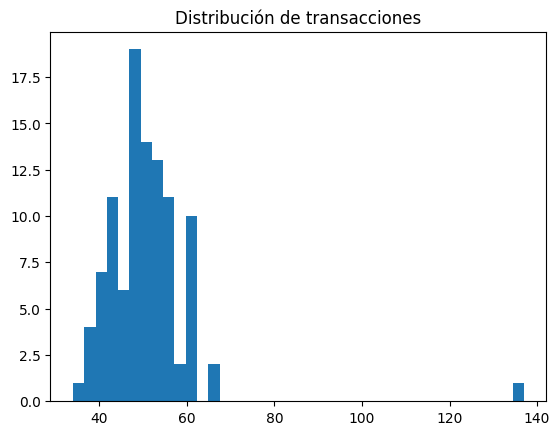

In [30]:
# ========= 8. HISTOGRAMA =========
plt.hist(conteo, bins=40)
plt.title("Distribución de transacciones")
plt.show()

In [31]:
# ========= 9. LIMPIAR TARJETAS NULAS =========
transacciones_filtradas = transacciones[transacciones["tarjeta"].notnull()]

conteo_filtrado = transacciones_filtradas["tarjeta"].value_counts()
print(conteo_filtrado)

tarjeta
96.0     66
100.0    65
57.0     62
74.0     62
11.0     61
         ..
67.0     39
56.0     39
6.0      39
5.0      37
34.0     34
Name: count, Length: 100, dtype: int64


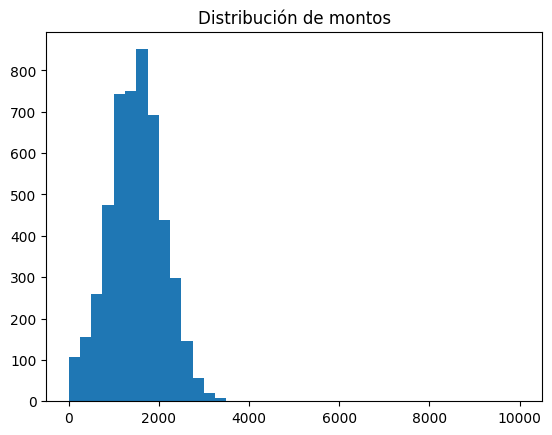

In [32]:
# ========= 10. HISTOGRAMA MONTO =========
plt.hist(transacciones_filtradas["monto"], bins=40)
plt.title("Distribución de montos")
plt.show()

In [33]:
# ========= 11. OUTLIERS =========
outliers = transacciones_filtradas[transacciones_filtradas["monto"] > 10000]
print(outliers)

Empty DataFrame
Columns: [tarjeta, monto, comercio, fecha, tipo]
Index: []


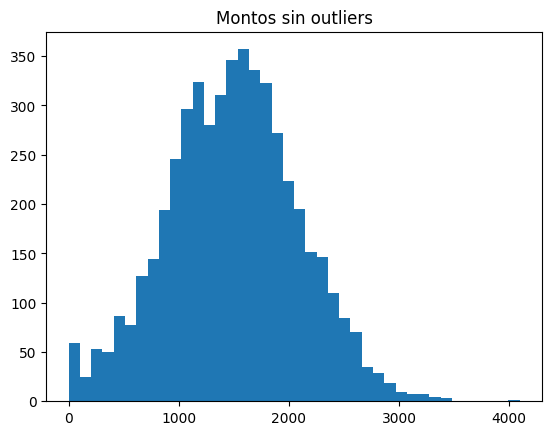

In [34]:
# ========= 12. ELIMINAR OUTLIERS =========
transacciones_filtradas = transacciones_filtradas[
    transacciones_filtradas["monto"] < 10000
]

plt.hist(transacciones_filtradas["monto"], bins=40)
plt.title("Montos sin outliers")
plt.show()

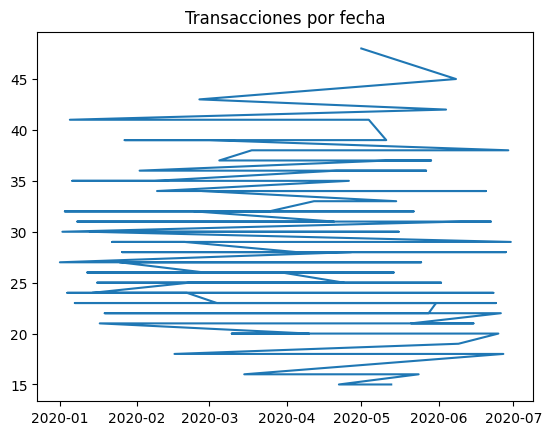

In [35]:

# ========= 13. TRANSACCIONES POR FECHA =========
conteo_fecha = transacciones_filtradas["fecha"].value_counts()

plt.plot(conteo_fecha)
plt.title("Transacciones por fecha")
plt.show()

In [37]:

# ========= 14. FEATURES DE FECHA =========
transacciones_filtradas["dia_semana"] = transacciones_filtradas["fecha"].dt.day_name()
transacciones_filtradas["mes"] = transacciones_filtradas["fecha"].dt.month
transacciones_filtradas["dia"] = transacciones_filtradas["fecha"].dt.day

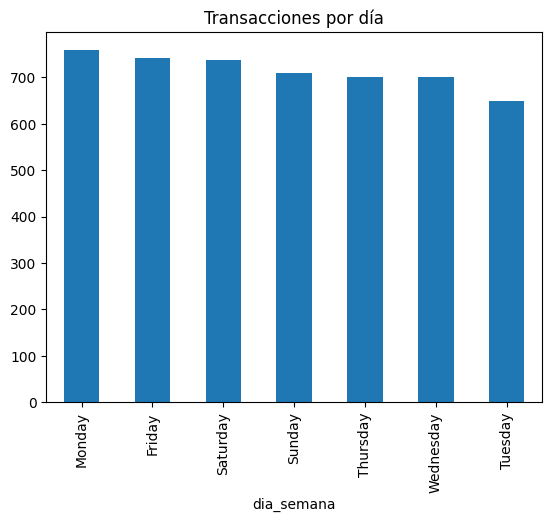

In [38]:
# ========= 15. GRAFICA DÍA =========
transacciones_filtradas["dia_semana"].value_counts().plot(kind="bar")
plt.title("Transacciones por día")
plt.show()


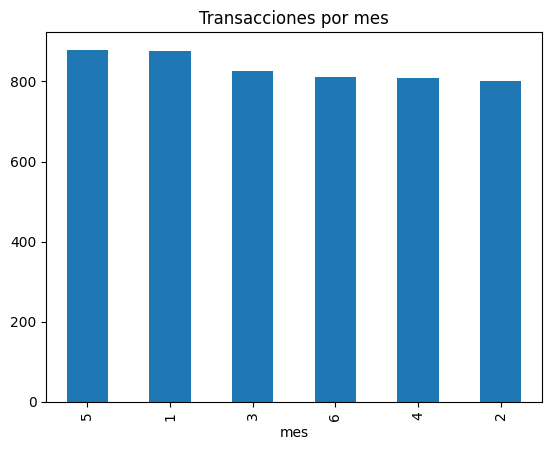

In [39]:
# ========= 16. GRAFICA MES =========
transacciones_filtradas["mes"].value_counts().plot(kind="bar")
plt.title("Transacciones por mes")
plt.show()


In [40]:
# ========= 17. TIPOS =========
print(transacciones_filtradas["tipo"].value_counts())

tipo
transaccion       4961
reconciliacion      38
Name: count, dtype: int64


In [41]:
# ========= 18. FILTRAR RECONCILIACION =========
transacciones_filtradas = transacciones_filtradas[
    transacciones_filtradas["tipo"] != "reconciliacion"
]

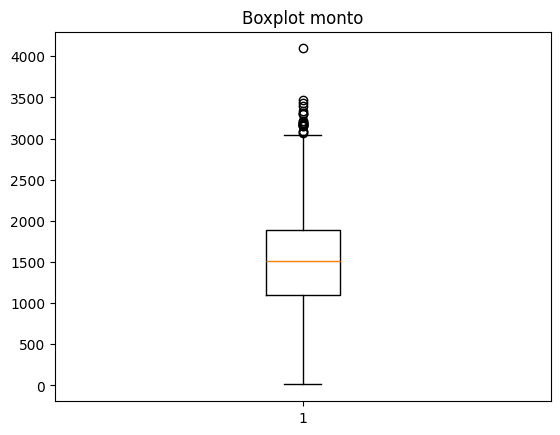

In [42]:
# ========= 19. BOXPLOT =========
plt.boxplot(transacciones_filtradas["monto"])
plt.title("Boxplot monto")
plt.show()

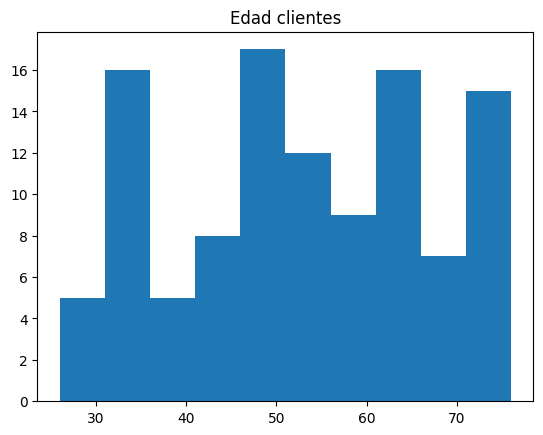

In [43]:
# ========= 20. EDAD =========
clientes["edad"] = (pd.Timestamp.now() - clientes["fecha_nacimiento"]).dt.days // 365

plt.hist(clientes["edad"], bins=10)
plt.title("Edad clientes")
plt.show()

In [44]:
# ========= 21. AÑO-MES =========
transacciones_filtradas["year"] = transacciones_filtradas["fecha"].dt.year
transacciones_filtradas["month"] = transacciones_filtradas["fecha"].dt.month

transacciones_filtradas["year_month"] = (
    transacciones_filtradas["year"].astype(str) + "-" +
    transacciones_filtradas["month"].astype(str)
)

fechas = transacciones_filtradas["year_month"].unique()


In [45]:
# ========= 22. VALIDAR DUPLICADOS TARJETA =========
tarjetas_gb = pd.DataFrame(
    clientes.groupby(['tarjeta']).size().reset_index(name='counts')
)

print(tarjetas_gb[tarjetas_gb.counts > 1])


Empty DataFrame
Columns: [tarjeta, counts]
Index: []


In [46]:
# ========= 23. CREAR DATAFRAME FECHAS =========
fechas = pd.DataFrame(fechas, columns=['fechaMA'])

print(fechas.head())

  fechaMA
0  2020-1
1  2020-2
2  2020-6
3  2020-5
4  2020-4


In [47]:
# ========= 24. CROSS JOIN =========
clientes["tmp"] = 1
fechas["tmp"] = 1

clientes_fechas = pd.merge(clientes, fechas, on="tmp")

clientes_fechas = clientes_fechas.drop(columns=["tmp"])

print(clientes_fechas.head())

  nombre    apellido  tarjeta fecha_nacimiento  edad fechaMA
0   Rosa  Barrientos        1       1984-12-19    41  2020-1
1   Rosa  Barrientos        1       1984-12-19    41  2020-2
2   Rosa  Barrientos        1       1984-12-19    41  2020-6
3   Rosa  Barrientos        1       1984-12-19    41  2020-5
4   Rosa  Barrientos        1       1984-12-19    41  2020-4


In [48]:
# ========= 25. MERGE FINAL =========
df = pd.merge(clientes, transacciones_filtradas, on="tarjeta")

In [49]:
# ========= 26. AGRUPACIÓN FINAL =========
resultado = df.groupby(["nombre","apellido"]).size().reset_index(name="counts")

print(resultado.sort_values(by="counts", ascending=False))

       nombre  apellido  counts
56       Juan     Perez     145
15     Andrés      Ruíz     112
14     Andrés    Rivera     104
51       Juan  Calderón     101
48       José  Coronado      99
..        ...       ...     ...
49       José    Garcia      39
82    Paulina  Coronado      39
11     Andrés  Martinez      38
71  Margarita     Muñoz      37
67       Luis    Rivera      34

[90 rows x 3 columns]
